In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
df=pd.read_csv("D:\yt series\Diabetes_Dataset.csv")
df.head(50)
df.tail(50)

,PatientID,Age,Gender,BMI,BloodPressure,GlucoseLevel,Insulin,SkinThickness,DiabetesPedigreeFunction,PhysicalActivity,Smoking,Alcohol_Intake,FamilyHistory
50,51,44,Male,28.4,82,145,125.0,30,0.58,Low,Yes,Moderate,Yes
51,52,33,Female,23.6,72,102,88.0,22,0.27,High,No,Low,No
52,53,56,Male,34.8,93,180,160.0,41,0.87,Low,Yes,High,Yes
53,54,38,Female,25.9,78,120,100.0,27,0.38,Medium,No,Moderate,No
54,55,47,Male,30.6,85,158,138.0,34,0.66,Low,Yes,Moderate,Yes
55,56,31,Female,24.2,73,108,90.0,24,0.31,High,No,Low,No
56,57,60,Male,35.5,96,190,170.0,43,0.92,Low,Yes,High,Yes
57,58,42,Female,27.3,80,135,115.0,30,0.51,Medium,No,Moderate,Yes
58,59,45,Male,29.1,83,148,128.0,31,0.60,Low,Yes,Moderate,Yes
59,60,36,Female,25.1,76,115,95.0,26,0.34,Medium,No,Low,No


In [5]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PatientID                 100 non-null    int64  
 1   Age                       100 non-null    int64  
 2   Gender                    100 non-null    str    
 3   BMI                       100 non-null    float64
 4   BloodPressure             100 non-null    int64  
 5   GlucoseLevel              100 non-null    int64  
 6   Insulin                   98 non-null     float64
 7   SkinThickness             100 non-null    int64  
 8   DiabetesPedigreeFunction  100 non-null    float64
 9   PhysicalActivity          100 non-null    str    
 10  Smoking                   100 non-null    str    
 11  Alcohol_Intake            100 non-null    str    
 12  FamilyHistory             100 non-null    str    
dtypes: float64(3), int64(5), str(5)
memory usage: 12.2 KB


,PatientID,Age,BMI,BloodPressure,GlucoseLevel,Insulin,SkinThickness,DiabetesPedigreeFunction
count,100.000000,100.000000,100.000000,100.00000,100.000000,98.000000,100.000000,100.000000
mean,50.500000,43.440000,28.534000,81.99000,141.830000,121.693878,30.860000,0.555500
std,29.011492,10.106823,4.360063,8.25661,33.537573,29.754115,6.893153,0.233309
min,1.000000,27.000000,21.800000,68.00000,95.000000,75.000000,18.000000,0.200000
25%,25.750000,35.750000,25.025000,75.75000,113.750000,92.750000,25.750000,0.337500
50%,50.500000,42.500000,28.100000,81.50000,142.500000,122.500000,30.000000,0.565000
75%,75.250000,50.000000,31.050000,88.00000,166.250000,144.250000,35.250000,0.727500
max,100.000000,63.000000,45.000000,110.00000,300.000000,200.000000,50.000000,1.200000


In [38]:
df['Gender'] = df['Gender'].astype(str).str.strip().str.lower()
df['Smoking'] = df['Smoking'].astype(str).str.strip().str.lower()
df['FamilyHistory'] = df['FamilyHistory'].astype(str).str.strip().str.lower()
df['PhysicalActivity'] = df['PhysicalActivity'].astype(str).str.strip().str.lower()
df['Alcohol_Intake'] = df['Alcohol_Intake'].astype(str).str.strip().str.lower()

In [39]:
df['Gender'] = df['Gender'].map({'male':1, 'female':0})
df['Smoking'] = df['Smoking'].map({'yes':1, 'no':0})
df['FamilyHistory'] = df['FamilyHistory'].map({'yes':1, 'no':0})
df['PhysicalActivity'] = df['PhysicalActivity'].map({'low':0, 'medium':1, 'high':2})
df['Alcohol_Intake'] = df['Alcohol_Intake'].map({'low':0, 'moderate':1, 'high':2})
df

,PatientID,Age,Gender,BMI,BloodPressure,GlucoseLevel,Insulin,SkinThickness,DiabetesPedigreeFunction,PhysicalActivity,Smoking,Alcohol_Intake,FamilyHistory
0,1,45,1,28.5,85,150,130.0,32,0.62,0,1,1,1
1,2,34,0,22.3,70,98,80.0,20,0.25,2,0,0,0
2,3,50,1,31.2,90,170,NaN,35,0.78,0,1,2,1
3,4,29,0,24.1,75,110,90.0,25,0.30,1,0,0,0
4,5,60,1,45.0,110,300,200.0,50,1.20,0,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,35,0,24.5,75,110,92.0,25,0.33,2,0,0,0
96,97,60,1,35.2,96,190,170.0,43,0.92,0,1,2,1
97,98,42,0,27.3,80,135,115.0,30,0.51,1,0,1,1
98,99,45,1,29.4,84,148,128.0,31,0.60,0,1,1,1


In [40]:
def assign_outcome(row):
    if (row['GlucoseLevel'] >= 140) or (row['BMI'] >= 30) or (row['FamilyHistory'] == 'Yes'):
        return 1
    return 0

df['Outcome'] = df.apply(assign_outcome, axis=1)
df

,PatientID,Age,Gender,BMI,BloodPressure,GlucoseLevel,Insulin,SkinThickness,DiabetesPedigreeFunction,PhysicalActivity,Smoking,Alcohol_Intake,FamilyHistory,Outcome
0,1,45,1,28.5,85,150,130.0,32,0.62,0,1,1,1,1
1,2,34,0,22.3,70,98,80.0,20,0.25,2,0,0,0,0
2,3,50,1,31.2,90,170,NaN,35,0.78,0,1,2,1,1
3,4,29,0,24.1,75,110,90.0,25,0.30,1,0,0,0,0
4,5,60,1,45.0,110,300,200.0,50,1.20,0,1,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,35,0,24.5,75,110,92.0,25,0.33,2,0,0,0,0
96,97,60,1,35.2,96,190,170.0,43,0.92,0,1,2,1,1
97,98,42,0,27.3,80,135,115.0,30,0.51,1,0,1,1,0
98,99,45,1,29.4,84,148,128.0,31,0.60,0,1,1,1,1


In [6]:
df['Gender'] = df['Gender'].str.capitalize()
print(df)

    PatientID  Age  Gender   BMI  BloodPressure  GlucoseLevel  Insulin  \
0           1   45    Male  28.5             85           150    130.0   
1           2   34  Female  22.3             70            98     80.0   
2           3   50    Male  31.2             90           170      NaN   
3           4   29  Female  24.1             75           110     90.0   
4           5   60    Male  45.0            110           300    200.0   
..        ...  ...     ...   ...            ...           ...      ...   
95         96   35  Female  24.5             75           110     92.0   
96         97   60    Male  35.2             96           190    170.0   
97         98   42  Female  27.3             80           135    115.0   
98         99   45    Male  29.4             84           148    128.0   
99        100   36  Female  25.2             76           115     95.0   

    SkinThickness  DiabetesPedigreeFunction PhysicalActivity Smoking  \
0              32                      

In [7]:
df.isnull().sum()

PatientID                   0
Age                         0
Gender                      0
BMI                         0
BloodPressure               0
GlucoseLevel                0
Insulin                     2
SkinThickness               0
DiabetesPedigreeFunction    0
PhysicalActivity            0
Smoking                     0
Alcohol_Intake              0
FamilyHistory               0
dtype: int64

In [42]:
df=df.fillna(df.mean(numeric_only=True))
print(df)

    PatientID  Age  Gender   BMI  BloodPressure  GlucoseLevel     Insulin  \
0           1   45       1  28.5             85           150  130.000000   
1           2   34       0  22.3             70            98   80.000000   
2           3   50       1  31.2             90           170  121.693878   
3           4   29       0  24.1             75           110   90.000000   
4           5   60       1  45.0            110           300  200.000000   
..        ...  ...     ...   ...            ...           ...         ...   
95         96   35       0  24.5             75           110   92.000000   
96         97   60       1  35.2             96           190  170.000000   
97         98   42       0  27.3             80           135  115.000000   
98         99   45       1  29.4             84           148  128.000000   
99        100   36       0  25.2             76           115   95.000000   

    SkinThickness  DiabetesPedigreeFunction  PhysicalActivity  Smoking  \
0

In [9]:
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)

0


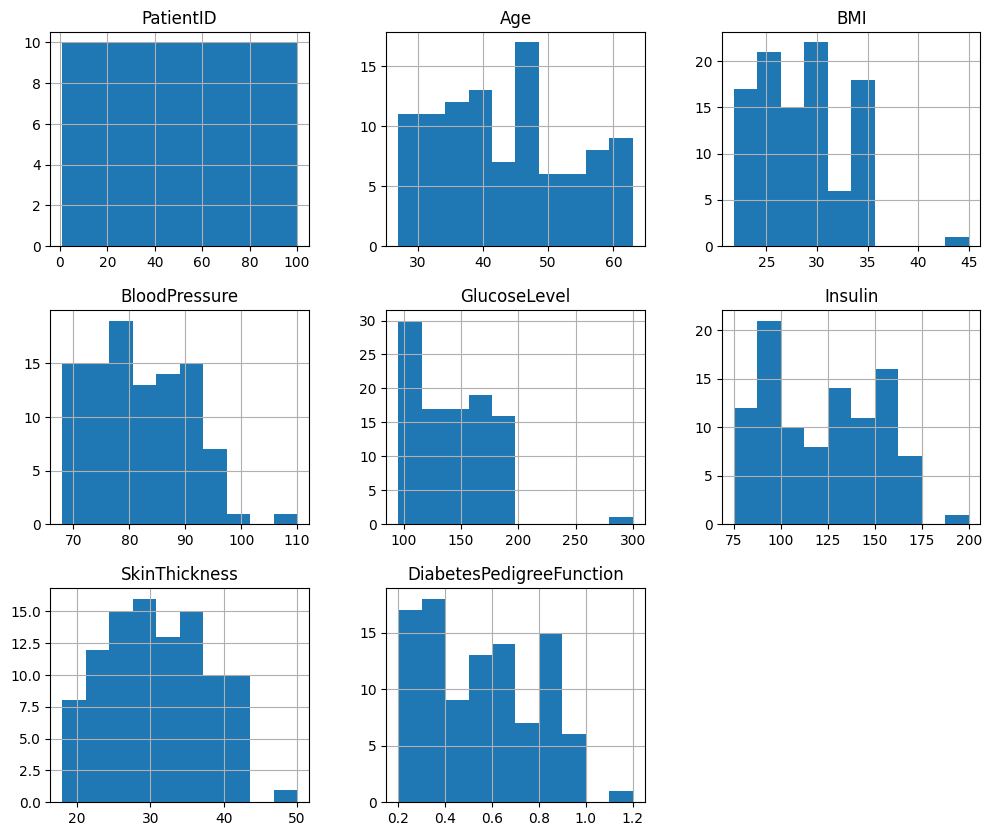

In [10]:
df.hist(figsize=(12,10))
plt.show()

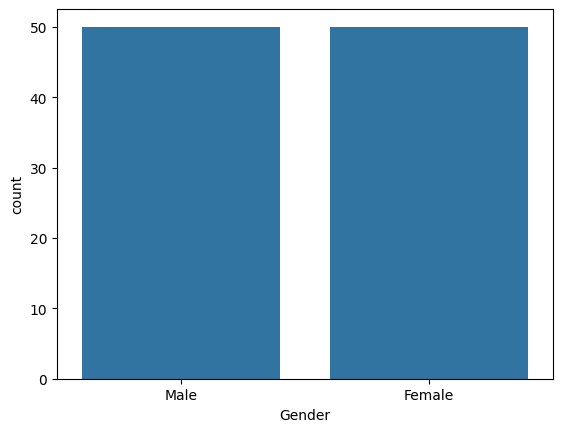

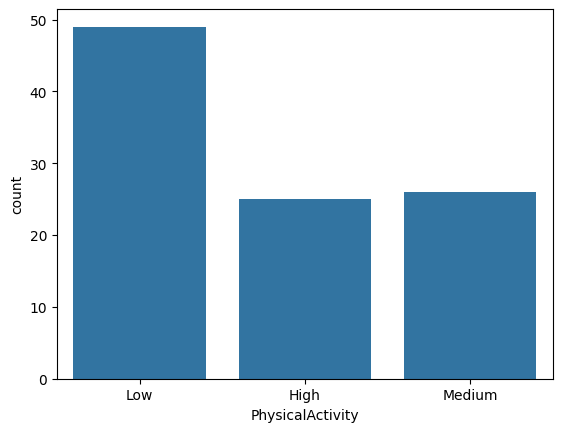

In [12]:
sns.countplot(x='Gender', data=df)
plt.show()
sns.countplot(x='PhysicalActivity', data=df)
plt.show()

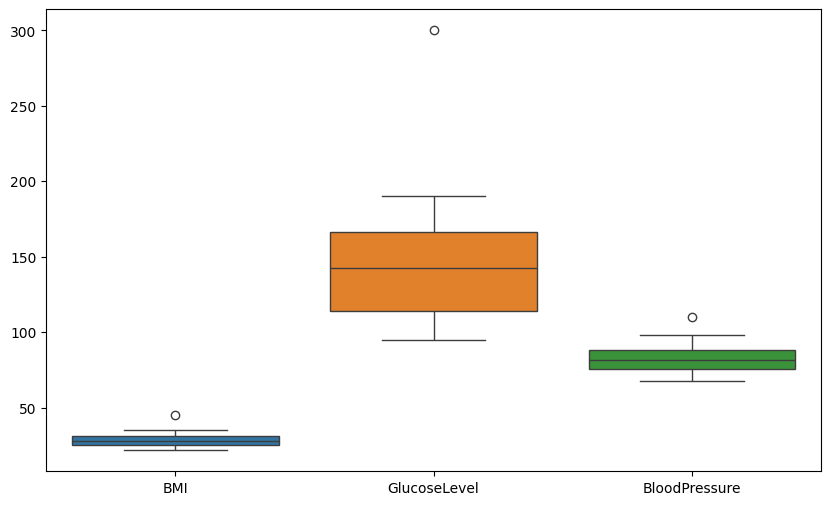

In [13]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[['BMI','GlucoseLevel','BloodPressure']])
plt.show()

In [14]:
Q1 = df['BMI'].quantile(0.25)
Q3 = df['BMI'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['BMI'] >= Q1 - 1.5*IQR) & (df['BMI'] <= Q3 + 1.5*IQR)]
df

,PatientID,Age,Gender,BMI,BloodPressure,GlucoseLevel,Insulin,SkinThickness,DiabetesPedigreeFunction,PhysicalActivity,Smoking,Alcohol_Intake,FamilyHistory
0,1,45,Male,28.5,85,150,130.000000,32,0.62,Low,Yes,Moderate,Yes
1,2,34,Female,22.3,70,98,80.000000,20,0.25,High,No,Low,No
2,3,50,Male,31.2,90,170,121.693878,35,0.78,Low,Yes,High,Yes
3,4,29,Female,24.1,75,110,90.000000,25,0.30,Medium,No,Low,No
5,6,41,Female,27.8,80,140,120.000000,30,0.55,Medium,No,Moderate,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,35,Female,24.5,75,110,92.000000,25,0.33,High,No,Low,No
96,97,60,Male,35.2,96,190,170.000000,43,0.92,Low,Yes,High,Yes
97,98,42,Female,27.3,80,135,115.000000,30,0.51,Medium,No,Moderate,Yes
98,99,45,Male,29.4,84,148,128.000000,31,0.60,Low,Yes,Moderate,Yes


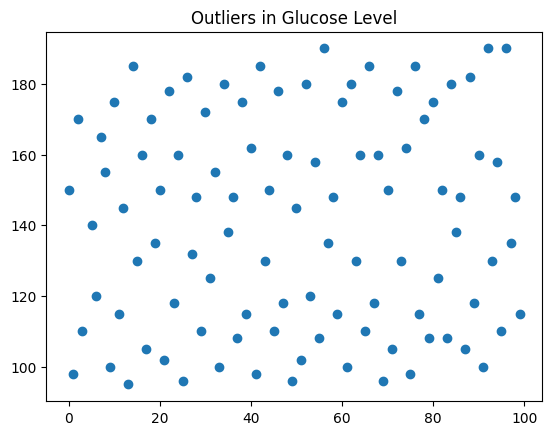

In [15]:
plt.scatter(df.index, df['GlucoseLevel'])
plt.title("Outliers in Glucose Level")
plt.show()

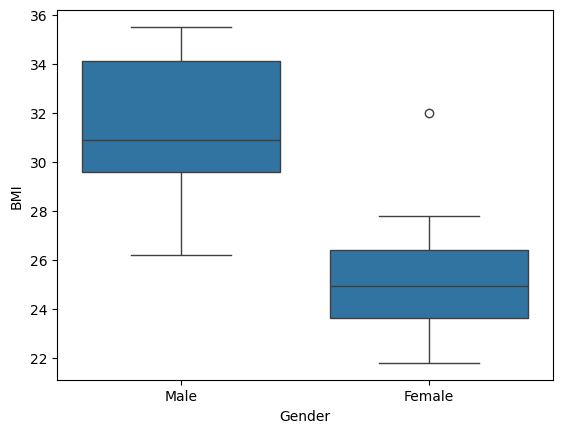

In [16]:
sns.boxplot(x='Gender', y='BMI', data=df)
plt.show()

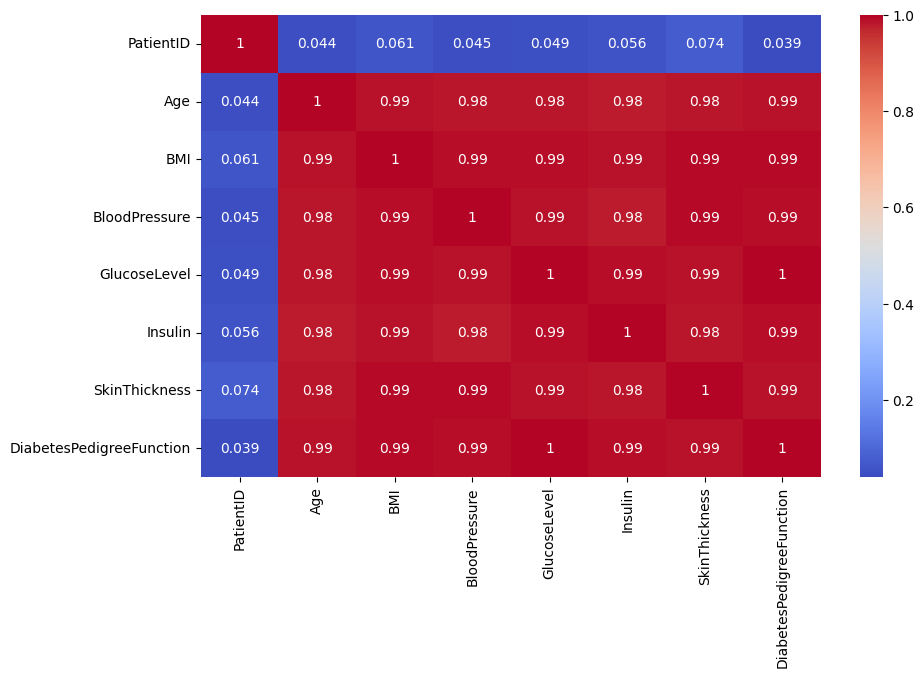

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [43]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,PatientID,Age,Gender,BMI,BloodPressure,GlucoseLevel,Insulin,SkinThickness,DiabetesPedigreeFunction,PhysicalActivity,Smoking,Alcohol_Intake,FamilyHistory,Outcome
0,1,45,1,28.5,85,150,130.000000,32,0.62,0,1,1,1,1
1,2,34,0,22.3,70,98,80.000000,20,0.25,2,0,0,0,0
2,3,50,1,31.2,90,170,121.693878,35,0.78,0,1,2,1,1
3,4,29,0,24.1,75,110,90.000000,25,0.30,1,0,0,0,0
4,5,60,1,45.0,110,300,200.000000,50,1.20,0,1,2,1,1


In [44]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols = ['Age','BMI','BloodPressure','GlucoseLevel','Insulin']
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])
df_encoded[num_cols]

,Age,BMI,BloodPressure,GlucoseLevel,Insulin
0,0.155129,-0.007837,0.366393,0.244835,2.834428e-01
1,-0.938728,-1.436999,-1.459486,-1.313476,-1.422785e+00
2,0.652336,0.614540,0.975019,0.844185,-4.849392e-16
3,-1.435935,-1.022081,-0.850859,-0.953866,-1.081540e+00
4,1.646751,3.795577,3.409524,4.739962,2.672162e+00
...,...,...,...,...,...
95,-0.839286,-0.929877,-0.850859,-0.953866,-1.013291e+00
96,1.646751,1.536579,1.705370,1.443535,1.648425e+00
97,-0.143196,-0.284449,-0.242233,-0.204678,-2.284256e-01
98,0.155129,0.199622,0.244668,0.184900,2.151937e-01


In [45]:
print(df.groupby('Gender')['GlucoseLevel'].mean())

Gender
0    115.26
1    168.40
Name: GlucoseLevel, dtype: float64


In [46]:
print(df.groupby('BloodPressure')['BMI'].mean())

BloodPressure
68     21.800000
69     22.100000
70     22.666667
71     23.500000
72     23.414286
73     24.225000
74     24.500000
75     24.540000
76     25.300000
77     25.700000
78     26.050000
79     26.600000
80     27.275000
81     26.900000
82     28.950000
83     28.960000
84     29.380000
85     30.071429
86     30.700000
88     31.500000
89     33.000000
90     32.933333
91     33.850000
92     34.150000
93     34.850000
94     34.500000
95     35.133333
96     35.366667
98     35.200000
110    45.000000
Name: BMI, dtype: float64


In [47]:
from scipy import stats
z_scores = np.abs(stats.zscore(df['BMI']))
df_clean = df[z_scores < 3]
print("Original Shape:", df.shape)
print("After Removing Outliers:", df_clean.shape)

Original Shape: (100, 14)
After Removing Outliers: (99, 14)


In [48]:
print("Mean:\n", df[['BMI','GlucoseLevel','BloodPressure']].mean())
print("\nMedian:\n", df[['BMI','GlucoseLevel','BloodPressure']].median())
print("\nMax:\n", df[['BMI','GlucoseLevel','BloodPressure']].max())
print("\nMin:\n", df[['BMI','GlucoseLevel','BloodPressure']].min())
print("\nStd Dev:\n", df[['BMI','GlucoseLevel','BloodPressure']].std())

Mean:
 BMI               28.534
GlucoseLevel     141.830
BloodPressure     81.990
dtype: float64

Median:
 BMI               28.1
GlucoseLevel     142.5
BloodPressure     81.5
dtype: float64

Max:
 BMI               45.0
GlucoseLevel     300.0
BloodPressure    110.0
dtype: float64

Min:
 BMI              21.8
GlucoseLevel     95.0
BloodPressure    68.0
dtype: float64

Std Dev:
 BMI               4.360063
GlucoseLevel     33.537573
BloodPressure     8.256610
dtype: float64


In [49]:
low_bmi = df[df['BMI'] < 20]
print(low_bmi)

Empty DataFrame
Columns: [PatientID, Age, Gender, BMI, BloodPressure, GlucoseLevel, Insulin, SkinThickness, DiabetesPedigreeFunction, PhysicalActivity, Smoking, Alcohol_Intake, FamilyHistory, Outcome]
Index: []


In [51]:
df['Age'] = df['Age'].apply(lambda x: abs(x))
df['Age']

0     45
1     34
2     50
3     29
4     60
      ..
95    35
96    60
97    42
98    45
99    36
Name: Age, Length: 100, dtype: int64